## MLP 3: Final Report (Updates start from section 9)
Project: Credit Card Fraud Detection<br>
Team Member: Hongru He<br>
Date: Mar 2026

### 1. Project Overview & Problem Statement

Goal: The objective of this project is to build a machine learning model to detect fraudulent credit card transactions. The dataset presents a binary classification problem where the positive class (Fraud, Class=1) is extremely rare compared to the negative class (Legitimate, Class=0).
+1

Current Phase: This notebook covers the data preprocessing, exploratory data analysis (EDA), feature selection, and the training of a baseline Binomial Logistic Regression model.

### 2. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, f1_score, roc_auc_score)

# Load Data
# Replace with your local path
df = pd.read_csv('../Dataset/creditcard.csv')

# Quick Shape Check
print(f"Dataset Shape: {df.shape}")
print(f"Class Distribution:\n{df['Class'].value_counts(normalize=True)}")

Dataset Shape: (284807, 31)
Class Distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


### 3. Exploratory Data Analysis (EDA) & Preprocessing
#### 3.1 Scaling Time and Amount
Since the "V" features are PCA-transformed (scaled), but Amount and Time are not, we must scale them. We use RobustScaler because the Amount column contains extreme outliers (high-value transactions) which would distort a standard scaler.

In [2]:
# Initialize RobustScaler
rob_scaler = RobustScaler()

# Scale and create new columns
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Drop original unscaled columns
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Move Class to the end for easier slicing
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

print("Data Scaled. First 5 rows:")
print(df.head())

Data Scaled. First 5 rows:
   scaled_amount  scaled_time        V1        V2        V3        V4  \
0       1.783274    -0.994983 -1.359807 -0.072781  2.536347  1.378155   
1      -0.269825    -0.994983  1.191857  0.266151  0.166480  0.448154   
2       4.983721    -0.994972 -1.358354 -1.340163  1.773209  0.379780   
3       1.418291    -0.994972 -0.966272 -0.185226  1.792993 -0.863291   
4       0.670579    -0.994960 -1.158233  0.877737  1.548718  0.403034   

         V5        V6        V7        V8  ...       V20       V21       V22  \
0 -0.338321  0.462388  0.239599  0.098698  ...  0.251412 -0.018307  0.277838   
1  0.060018 -0.082361 -0.078803  0.085102  ... -0.069083 -0.225775 -0.638672   
2 -0.503198  1.800499  0.791461  0.247676  ...  0.524980  0.247998  0.771679   
3 -0.010309  1.247203  0.237609  0.377436  ... -0.208038 -0.108300  0.005274   
4 -0.407193  0.095921  0.592941 -0.270533  ...  0.408542 -0.009431  0.798278   

        V23       V24       V25       V26       V27  

### 4. Feature Selection Strategy
Constraint: We aim to select only the top 5-8 "V" features to reduce noise and dimensionality.

We will use two methods to decide which features to keep:

1. Pearson Correlation: To see which features linearly correlate with the Class (Fraud).
2. Tree-Based Feature Importance: Using a lightweight Random Forest to capture non-linear importance.

#### Method 1: Correlation Matrix

--- Top Positive Correlations (Fraud increases as feature increases) ---
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
Name: Class, dtype: float64

--- Top Negative Correlations (Fraud increases as feature decreases) ---
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


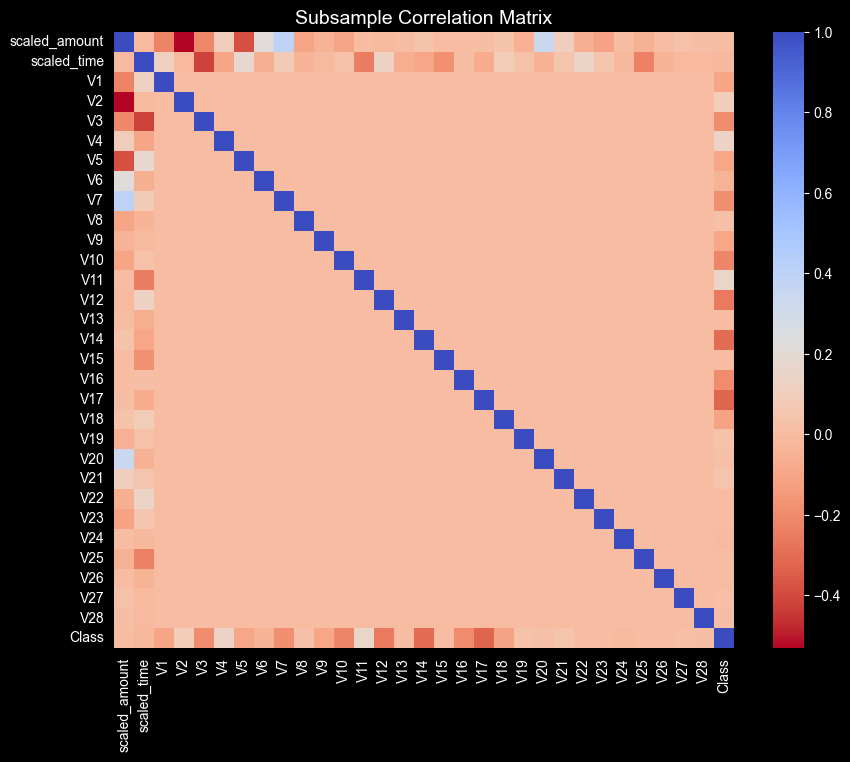

In [27]:
# Calculate correlation of all features with 'Class'
correlation = df.corr()
class_corr = correlation['Class'].sort_values(ascending=False)

print("--- Top Positive Correlations (Fraud increases as feature increases) ---")
print(class_corr.head(5))

print("\n--- Top Negative Correlations (Fraud increases as feature decreases) ---")
print(class_corr.tail(5))

# Visualization
plt.figure(figsize=(10,8))
sns.heatmap(correlation, cmap='coolwarm_r', annot_kws={'size':20})
plt.title('Subsample Correlation Matrix', fontsize=14)
plt.show()

#### Method 2: Random Forest Importance
We fit a simple Random Forest to extract feature importance scores. This validates if the correlated features are actually useful for splitting the data.

In [4]:
# Define X and y for feature selection
X_temp = df.drop('Class', axis=1)
y_temp = df['Class']

# Fit a small Random Forest
rf_selector = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_selector.fit(X_temp, y_temp)

# Get Importance
importances = pd.Series(rf_selector.feature_importances_, index=X_temp.columns)
print("\n--- Top 8 Features by Random Forest Importance ---")
print(importances.sort_values(ascending=False).head(8))


--- Top 8 Features by Random Forest Importance ---
V14    0.172157
V12    0.158660
V17    0.131950
V11    0.057344
V10    0.053689
V16    0.047970
V9     0.035901
V4     0.033467
dtype: float64


#### Method 3: Kernel Density Estimation

Generating 28 KDE plots. This may take a few seconds...


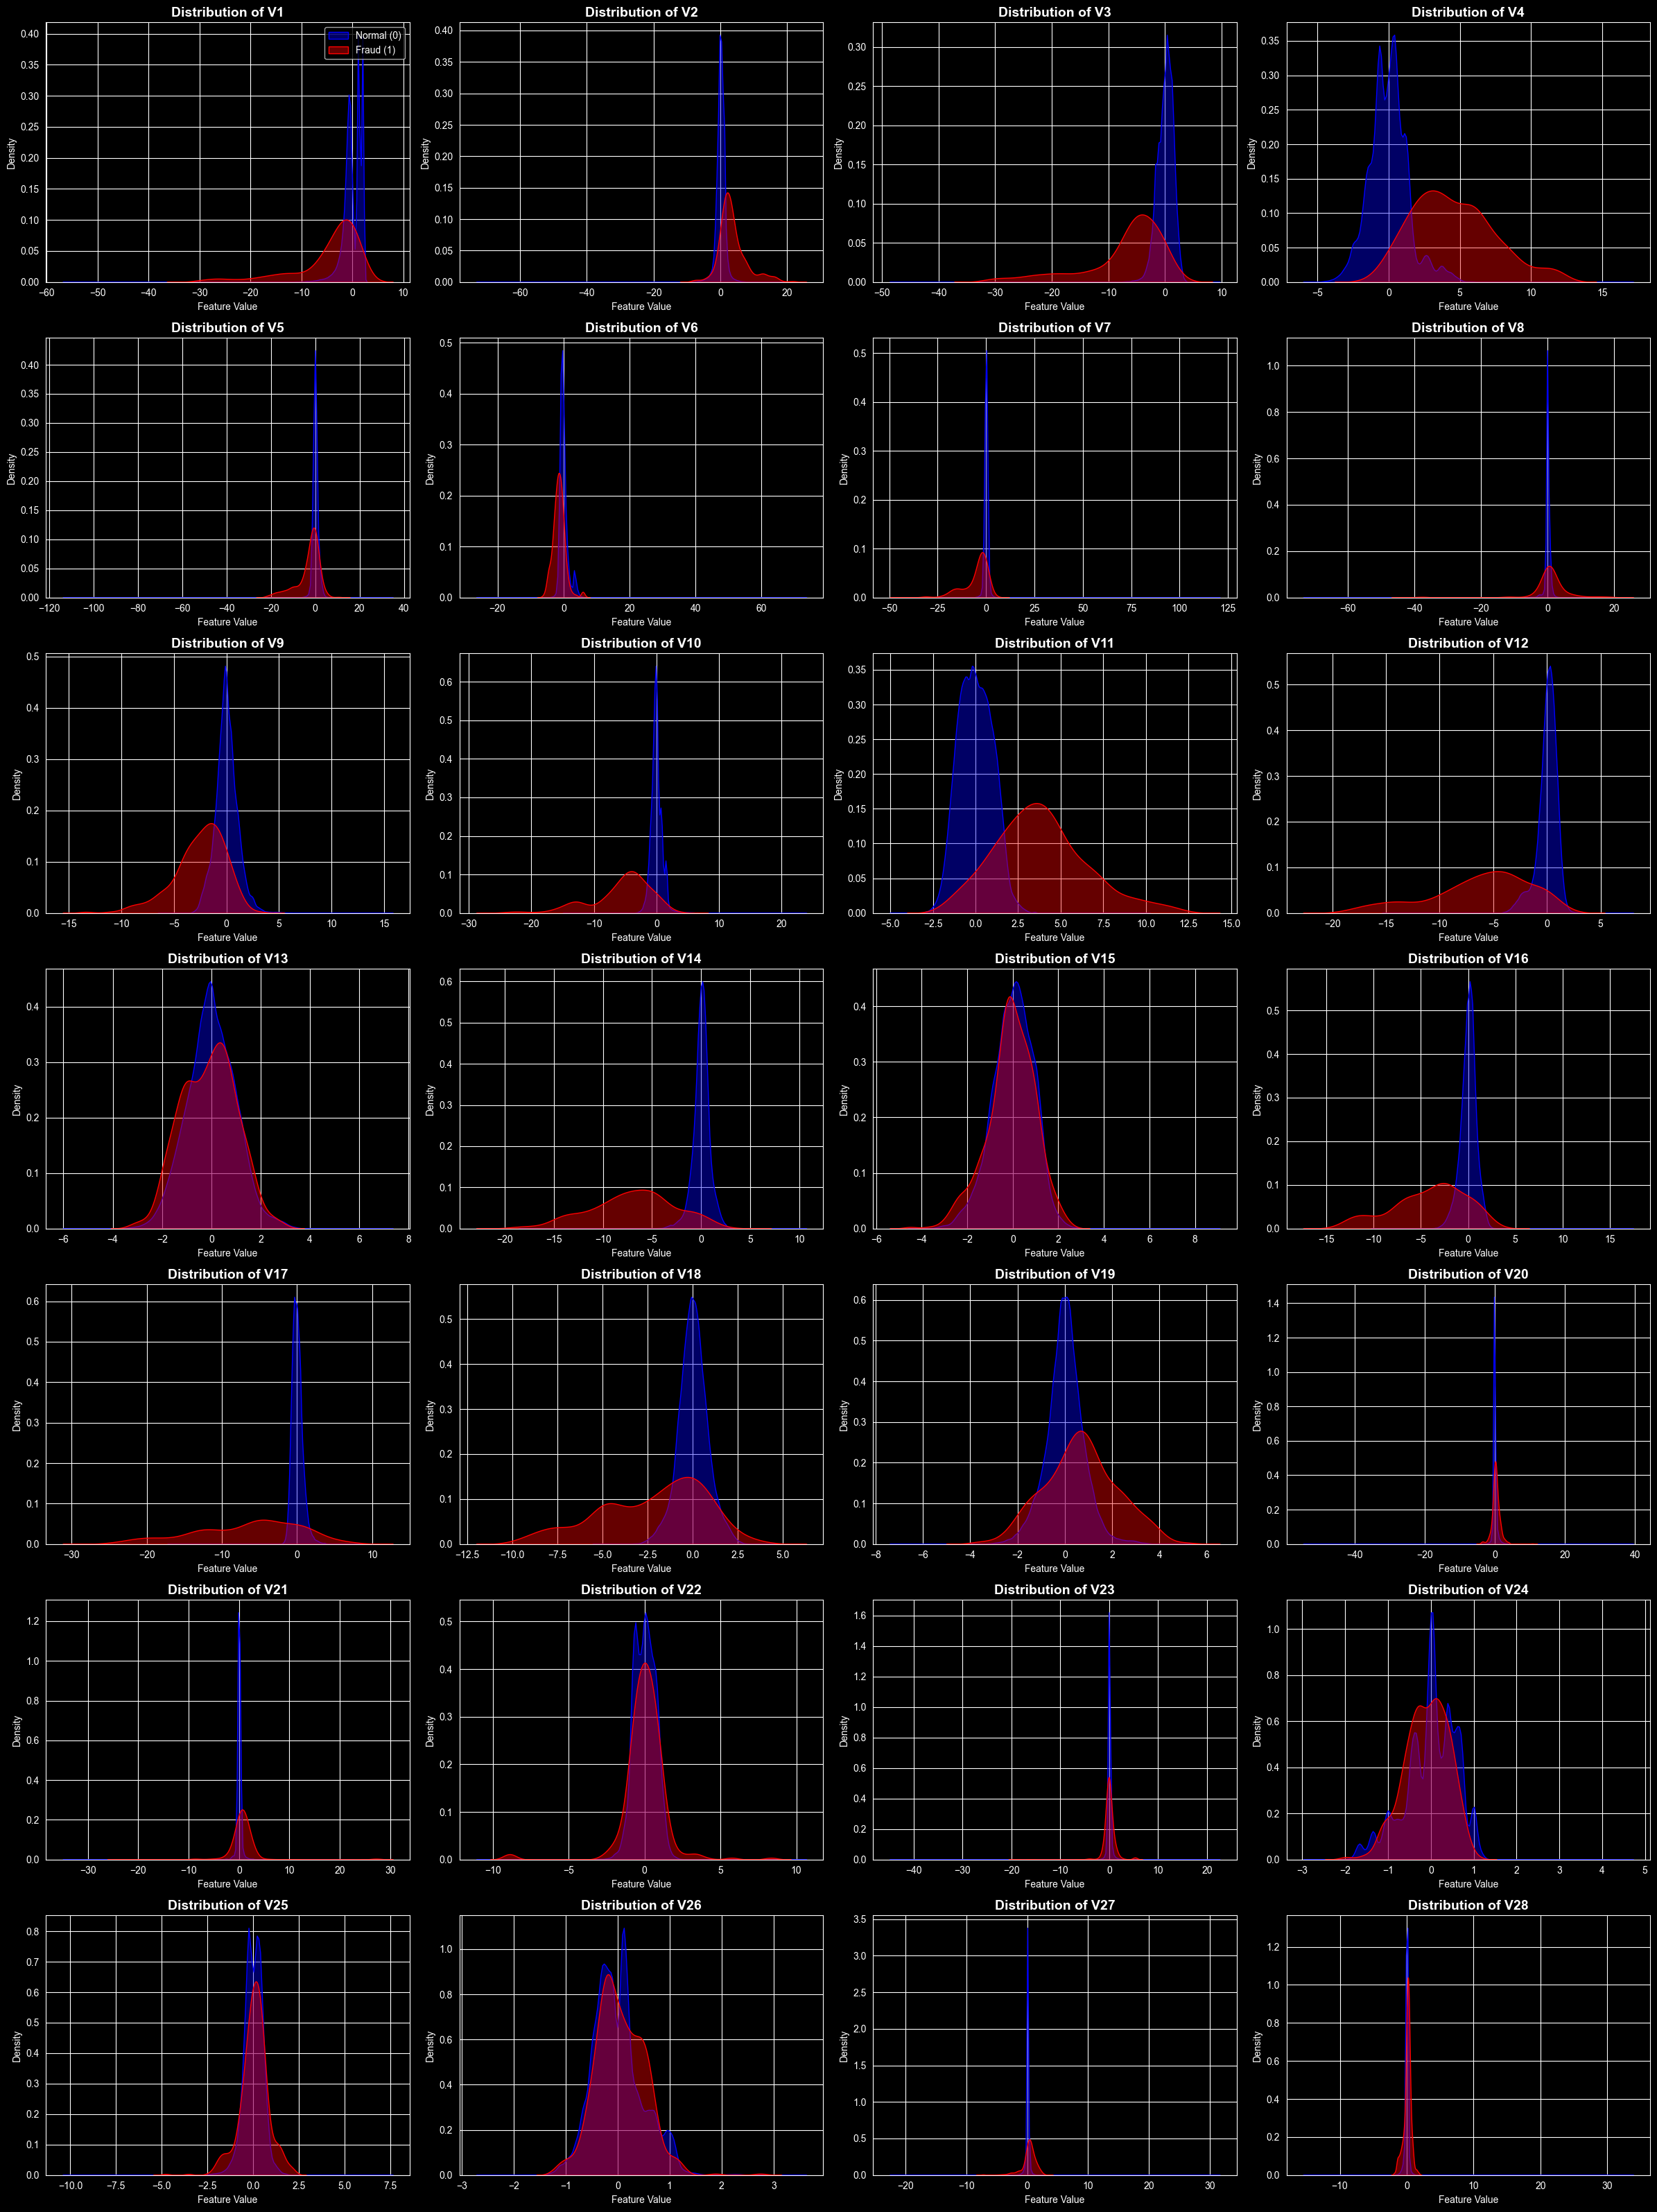

In [5]:
# 1. Prepare the Data for Plotting
df_normal_sample = (df[df['Class'] == 0])
df_fraud = df[df['Class'] == 1]
df_plot = pd.concat([df_normal_sample, df_fraud])

# Generate the list of V features (V1 to V28)
v_features = [f'V{i}' for i in range(1, 29)]

# 2. Set up the Matplotlib Grid (7 rows x 4 columns = 28 plots)
fig, axes = plt.subplots(nrows=7, ncols=4, figsize=(24, 32))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# 3. Loop through and plot each feature
print("Generating 28 KDE plots. This may take a few seconds...")

for i, col in enumerate(v_features):
    # Plot Normal Transactions (Blue)
    sns.kdeplot(data=df_plot[df_plot['Class'] == 0][col],
                label='Normal (0)', fill=True, color='blue', ax=axes[i], alpha=0.4)

    # Plot Fraud Transactions (Red)
    sns.kdeplot(data=df_plot[df_plot['Class'] == 1][col],
                label='Fraud (1)', fill=True, color='red', ax=axes[i], alpha=0.4)

    # Formatting
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Feature Value')
    axes[i].set_ylabel('Density')

    # Only show the legend on the very first plot to save space
    if i == 0:
        axes[i].legend(loc='upper right')

# Adjust layout to prevent overlapping titles
plt.tight_layout()
plt.show()

#### Drop the scaled_time column

In [6]:
# 1. Quantitative Analysis: Pearson Correlation on Scaled Time
time_corr = df['scaled_time'].corr(df['Class'])
print(f"Pearson Correlation between Scaled Time and Class: {time_corr:.5f}")

Pearson Correlation between Scaled Time and Class: -0.01232


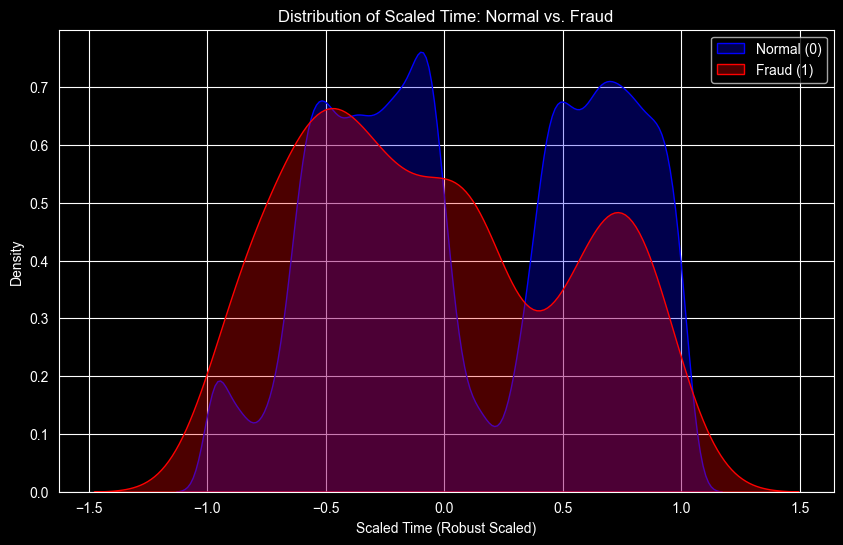

In [7]:
# 2. Qualitative Analysis: Distribution Overlap
plt.figure(figsize=(10, 6))

# Plotting the density of Scaled Time for both classes
sns.kdeplot(df[df['Class'] == 0]['scaled_time'], label='Normal (0)', fill=True, color='blue', alpha=0.3)
sns.kdeplot(df[df['Class'] == 1]['scaled_time'], label='Fraud (1)', fill=True, color='red', alpha=0.3)

plt.title('Distribution of Scaled Time: Normal vs. Fraud')
plt.xlabel('Scaled Time (Robust Scaled)')
plt.ylabel('Density')
plt.legend()
plt.show()

**Decision:** Drop the `Time` feature.
> To ensure a fair evaluation, we first applied a RobustScaler to the Time feature. Despite this normalization, quantitative analysis shows a near-zero correlation (-0.012) with the target variable. Furthermore, visual distribution analysis confirms that fraudulent transactions largely mirror the temporal frequency of normal transactions, exhibiting massive overlap.

> Beyond the statistical overlap, there is a fundamental real-world deployment constraint. Time acts as a cumulative counter from an arbitrary starting point. In a live production environment, the model would not have a meaningful baseline "first transaction" to measure against. Retaining this feature risks the model learning non-generalizable, spurious patterns. Consequently, it is permanently dropped from the pipeline.

#### 4.1 Final Feature Selection
Based on the intersection of Method 1 (Correlation) and Method 2 (RF Importance), we select the following subset of features.

In [8]:
# Example selection (Adjust based on your real output):
selected_features = ['V14', 'V12', 'V17', 'V11', 'V10', 'V16', 'scaled_amount']

print(f"Selected Features: {selected_features}")

# Create the final training data
X = df[selected_features]
y = df['Class']

Selected Features: ['V14', 'V12', 'V17', 'V11', 'V10', 'V16', 'scaled_amount']


### 5. Splitting and Modeling (The Baseline)
We split the data Stratified to ensure the fraction of fraud (0.17%) is maintained in both training and test sets.

In [9]:
# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Baseline Model: Binomial Logistic Regression
# solver='liblinear': Optimized for binary classification
# class_weight='balanced': Crucial for handling the imbalance (0.17% fraud)
log_reg = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)

# Train
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_probs_baseline = log_reg.predict_proba(X_test)[:, 1]

print("Baseline Model Trained Successfully.")

Baseline Model Trained Successfully.


### 6. Evaluation: The Two Scenarios
We analyze the results based on two conflicting business goals: High Recall (Catching Fraud) vs. High Precision (Reducing False Alarms).

#### 6.1 Baseline Performance

In [10]:
print("--- Classification Report (Baseline) ---")
print(classification_report(y_test, y_pred))

--- Classification Report (Baseline) ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.90      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.99     56962




--- Confusion Matrix ---


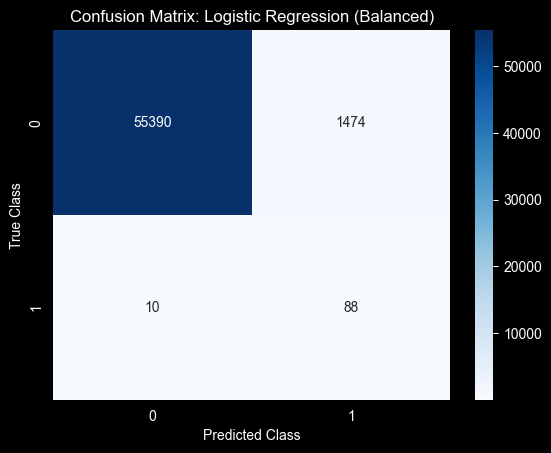

In [11]:
print("\n--- Confusion Matrix ---")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression (Balanced)")
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

#### 6.2 Precision-Recall Trade-off
Since accuracy is misleading, we plot the PR Curve to see how our model behaves across different thresholds.

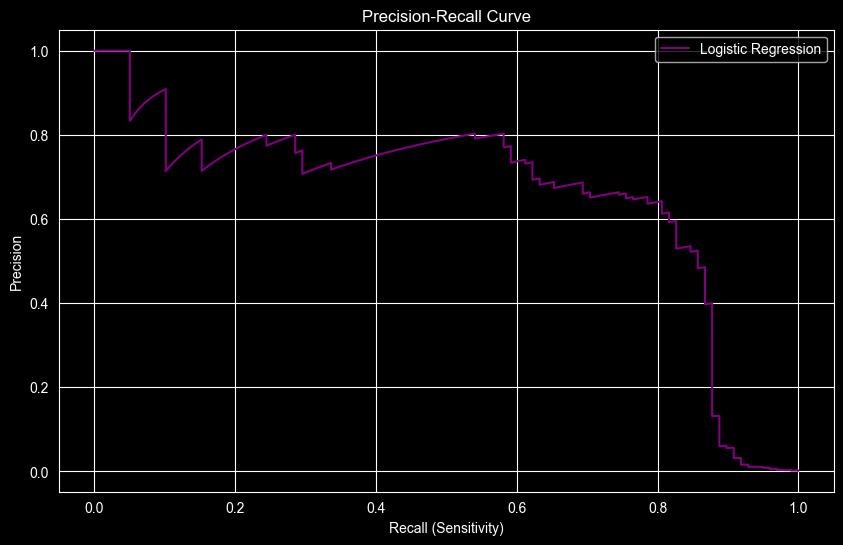

In [12]:
y_scores = log_reg.decision_function(X_test)
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='purple', label='Logistic Regression')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()

#### 6.3 Discussion of Scenarios

##### Scenario A: The "Recall-First" Strategy (Safety Focus)

- Goal: The bank guarantees that virtually no fraud slips through.
- Current Model Performance: With class_weight='balanced', our model likely defaults to this behavior.
- Observation: Look at the Recall score for Class 1 in the report above. If it is > 0.85, we are succeeding here.
- Trade-off: The Precision is likely low (lots of false alarms). This annoys customers but protects funds.

##### Scenario B: The "Precision-First" Strategy (User Experience Focus)

- Goal: The bank wants to ensure that if a card is declined, it is almost certainly fraud.
- Current Model Performance: Our baseline likely struggles here (Precision for Class 1 is probably < 0.10).
- Gap: To achieve this, we would need to move the decision threshold (e.g., only flag if probability > 0.9) or use a more complex model (like XGBoost) in the next phase.

### 7. Current Challenges & Obstacles
- Precision/Recall Trade-off: The baseline Logistic Regression achieves high recall but suffers from very low precision (many false positives).
- Feature Selection: Reducing 28 features to 6-8 risks losing subtle information, though it improves interpretability.
- Imbalance: Even with `class_weight='balanced'`, the model is biased by the sheer volume of normal transactions.

### 8. Plan for Completion

Next Steps:
1. Address Imbalance: Implement SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic fraud cases, which should improve the decision boundary.
2. Hyperparameter Tuning: Use GridSearchCV to optimize the C (regularization) parameter of the Logistic Regression.
3. Threshold Moving: Experiment with changing the decision threshold from 0.5 to optimize the F1-score.
4. Final Evaluation: Compare the Optimized Baseline against the current Baseline using the Area Under the Precision-Recall Curve (AUPRC).

### 9. Handle Imbalance with SMOTE and Hyperparameter Tuning
#### SMOTE

In [13]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.model_selection import GridSearchCV

# Reload the dataset
X_opt = df[selected_features]
y_opt = df['Class']

# Split train and test sets
X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(X_opt, y_opt, test_size=0.2, random_state=42, stratify=y_opt)

# Create a pipeline that combines SMOTE with Logistic Regression
pipeline = imbpipeline(steps=[
    ['smote', SMOTE(random_state=42)],
    ['classifier', LogisticRegression(max_iter=1000, solver='liblinear')]
])

#### Hyperparameter Tuning

In [14]:
# Parameter grid for C (Regularization strength)
param_grid = {'classifier__C': [0.01, 0.1, 1, 10, 100]}

# Using AUPRC (average_precision) as the scoring metric for the grid search
grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=param_grid,
                           scoring='average_precision',
                           cv=5,
                           n_jobs=-1)

grid_search.fit(X_train_opt, y_train_opt)

best_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

Best parameters: {'classifier__C': 0.01}


### 10. Threshold Moving for High Recall

In [17]:
# Get probability predictions for the positive class
y_probs_lr_opt = best_model.predict_proba(X_test_opt)[:, 1]

# Calculate Precision-Recall pairs for different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test_opt, y_probs_lr_opt)

# Find the highest threshold that maintains at least 85% Recall
target_recall = 0.85
idx = np.where(recalls >= target_recall)[0][-1]
best_threshold = thresholds[idx]

# Apply the custom threshold to generate final predictions
y_pred_custom = (y_probs_lr_opt >= best_threshold).astype(int)

print(f"Optimal Threshold for {target_recall} Recall: {best_threshold:.4f}")

Optimal Threshold for 0.85 Recall: 0.9696


### 11. Final Evaluation (AUPRC & Confusion Matrix)
#### 11.1 Classification Report

In [18]:
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay

print("\n--- Final Classification Report ---")
print(classification_report(y_test_opt, y_pred_custom))


--- Final Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.56      0.86      0.68        98

    accuracy                           1.00     56962
   macro avg       0.78      0.93      0.84     56962
weighted avg       1.00      1.00      1.00     56962



#### 11.2 Confusion Matrix

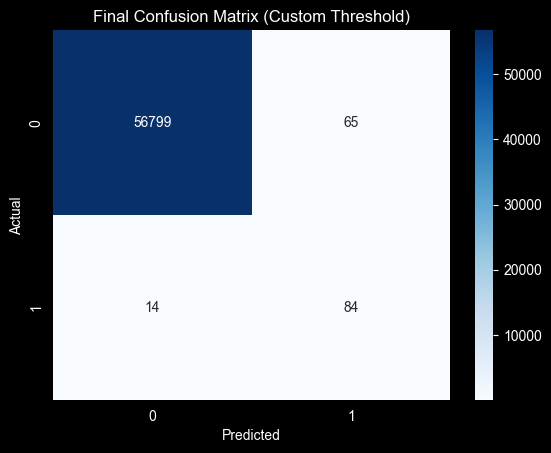

In [19]:
sns.heatmap(confusion_matrix(y_test_opt, y_pred_custom), annot=True, fmt='d', cmap='Blues')
plt.title('Final Confusion Matrix (Custom Threshold)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#### 11.3 P-R Curve and AUPRC

In [20]:
auprc = average_precision_score(y_test_opt, y_probs_lr_opt)
print(f"Area Under Precision-Recall Curve (AUPRC): {auprc:.4f}")

Area Under Precision-Recall Curve (AUPRC): 0.6705


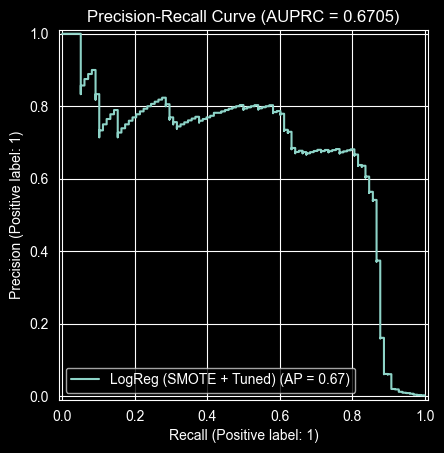

In [21]:
display = PrecisionRecallDisplay.from_estimator(best_model, X_test_opt, y_test_opt, name="LogReg (SMOTE + Tuned)")
plt.title(f"Precision-Recall Curve (AUPRC = {auprc:.4f})")
plt.show()

### 12. Appendix: Credit Card Fraud ML Workflow

In [22]:
from diagrams import Cluster, Diagram, Edge
from diagrams.programming.language import Python
from diagrams.generic.storage import Storage
from diagrams.generic.device import Mobile

with Diagram("Credit Card Fraud ML Workflow", show=False, direction="LR"):
    data = Storage("Transaction Data")

    with Cluster("Preprocessing"):
        pipe = [Python("RobustScaler"),
                Python("Feature Selection")]

    with Cluster("Training (SMOTE + Tuning)"):
        model = Python("Logistic Regression")

    with Cluster("Deployment"):
        inference = Python("Inference Engine")
        user_alert = Mobile("SMS Alert")

    data >> pipe >> model >> inference >> user_alert

### 13. Appendix: Extra Model - XGBoost
#### 13.1 Implementation of XGBoost

In [23]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report

# Reload the dataset
X_xg = df[selected_features]
y_xg = df['Class']

# Split the train and test sets
X_train_xg, X_test_xg, y_train_xg, y_test_xg = train_test_split(X_xg, y_xg, test_size=0.2, random_state=42, stratify=y_xg)

# Calculate scale_pos_weight
# Formula: count(negative) / count(positive)
counter = y_train_xg.value_counts()
estimate = counter[0] / counter[1]
print(f"Estimate for scale_pos_weight: {estimate:.2f}")

Estimate for scale_pos_weight: 577.29


In [24]:
# Define the XGBoost Model
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=estimate, # Handles imbalance without SMOTE
    eval_metric='aucpr',       # Optimize for Area Under PR Curve
    random_state=42
)

# Hyperparameter Tuning (RandomizedSearch for efficiency)
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 500],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    xgb_model, param_distributions=param_grid,
    n_iter=10, scoring='average_precision',
    cv=3, verbose=1, n_jobs=-1
)

random_search.fit(X_train_xg, y_train_xg)
best_xgb = random_search.best_estimator_

print(f"Best Parameters: {random_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


#### 13.2 Threshold Moving and Evaluation

In [25]:
# Get probabilities
y_probs_xg = best_xgb.predict_proba(X_test_xg)[:, 1]

# Calculate PR Curve
precisions, recalls, thresholds = precision_recall_curve(y_test_xg, y_probs_xg)

# Find threshold where Recall is at least 0.85
target_recall = 0.85
idx = np.where(recalls >= target_recall)[0][-1]
custom_threshold = thresholds[idx]

# Apply threshold
y_pred_custom = (y_probs_xg >= custom_threshold).astype(int)

print(f"Selected Threshold: {custom_threshold:.4f}")
print("\n--- XGBoost Final Evaluation ---")
print(classification_report(y_test_xg, y_pred_custom))
print(f"AUPRC Score: {average_precision_score(y_test_xg, y_probs_xg):.4f}")

Selected Threshold: 0.7509

--- XGBoost Final Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.86      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962

AUPRC Score: 0.8742


### 14. Compare Three Models with Precision-Recall Overlay

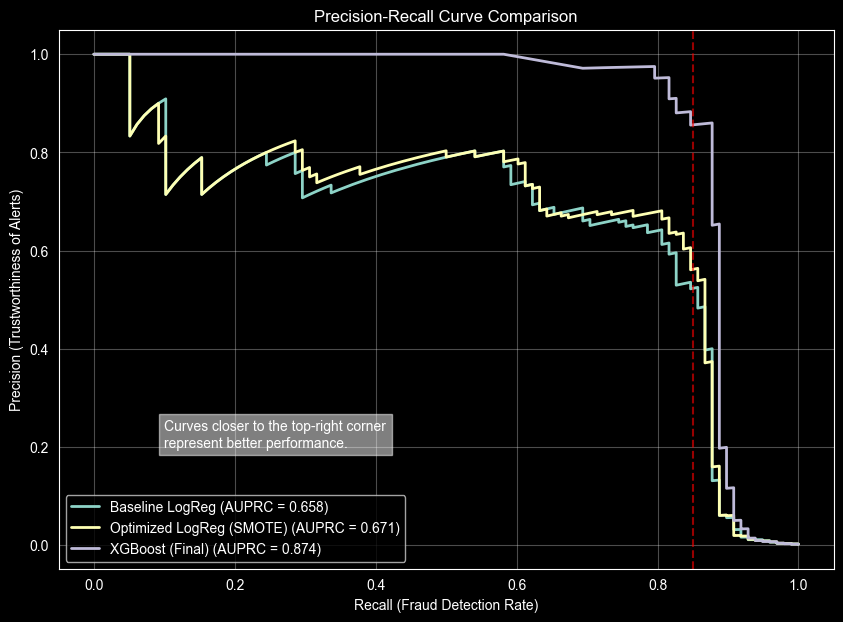

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate PR curves for each model
models = {
    'Baseline LogReg': y_probs_baseline,
    'Optimized LogReg (SMOTE)': y_probs_lr_opt,
    'XGBoost (Final)': y_probs_xg
}

plt.figure(figsize=(10, 7))

for name, probs in models.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    auprc = average_precision_score(y_test, probs)
    plt.plot(recall, precision, label=f'{name} (AUPRC = {auprc:.3f})', lw=2)

plt.xlabel('Recall (Fraud Detection Rate)')
plt.ylabel('Precision (Trustworthiness of Alerts)')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.axvline(x=0.85, color='red', linestyle='--', alpha=0.6, label='Recall Target (0.85)')

# Add a text annotation to explain the plot to non-technical audiences
plt.text(0.1, 0.2, "Curves closer to the top-right corner\nrepresent better performance.",
         bbox=dict(facecolor='white', alpha=0.5))

plt.show()